# 15 · Reddit Labeled Data EDA

Exploratory analysis of the 1k GPT-oss-120B labeled Reddit dataset produced by notebook `09`.  
Covers: class distributions, cross-tabulations, constraint enforcement, label quality, and sample inspection.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 60)

LABELED_FILE = Path("../data/processed/REDDIT MEDIA/reddit_labels_checkpoint.jsonl")

records = [json.loads(l) for l in LABELED_FILE.read_text(encoding="utf-8").splitlines() if l.strip()]
df = pd.DataFrame(records)
df["created_utc"] = pd.to_datetime(df["created_utc"], unit="s", utc=True)

# Canonical column order
LABEL_COLS = ["content_type", "sarcasm_irony_score", "sentiment_strength",
              "target_pair", "risk_sentiment", "target_clarity", "stance_clarity"]

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['created_utc'].min().date()} → {df['created_utc'].max().date()}")
print(f"Null check:\n{df[LABEL_COLS].isna().sum().to_string()}")

Records: 1,381
Columns: ['id', 'subreddit', 'title', 'body', 'flair', 'score', 'created_utc', 'reasoning', 'content_type', 'sarcasm_irony_score', 'sentiment_strength', 'target_pair', 'risk_sentiment', 'target_clarity', 'stance_clarity']

Date range: 2021-01-03 → 2025-12-31
Null check:
content_type              0
sarcasm_irony_score       0
sentiment_strength        0
target_pair            1253
risk_sentiment            0
target_clarity            0
stance_clarity            0


## 1 · Class Distributions

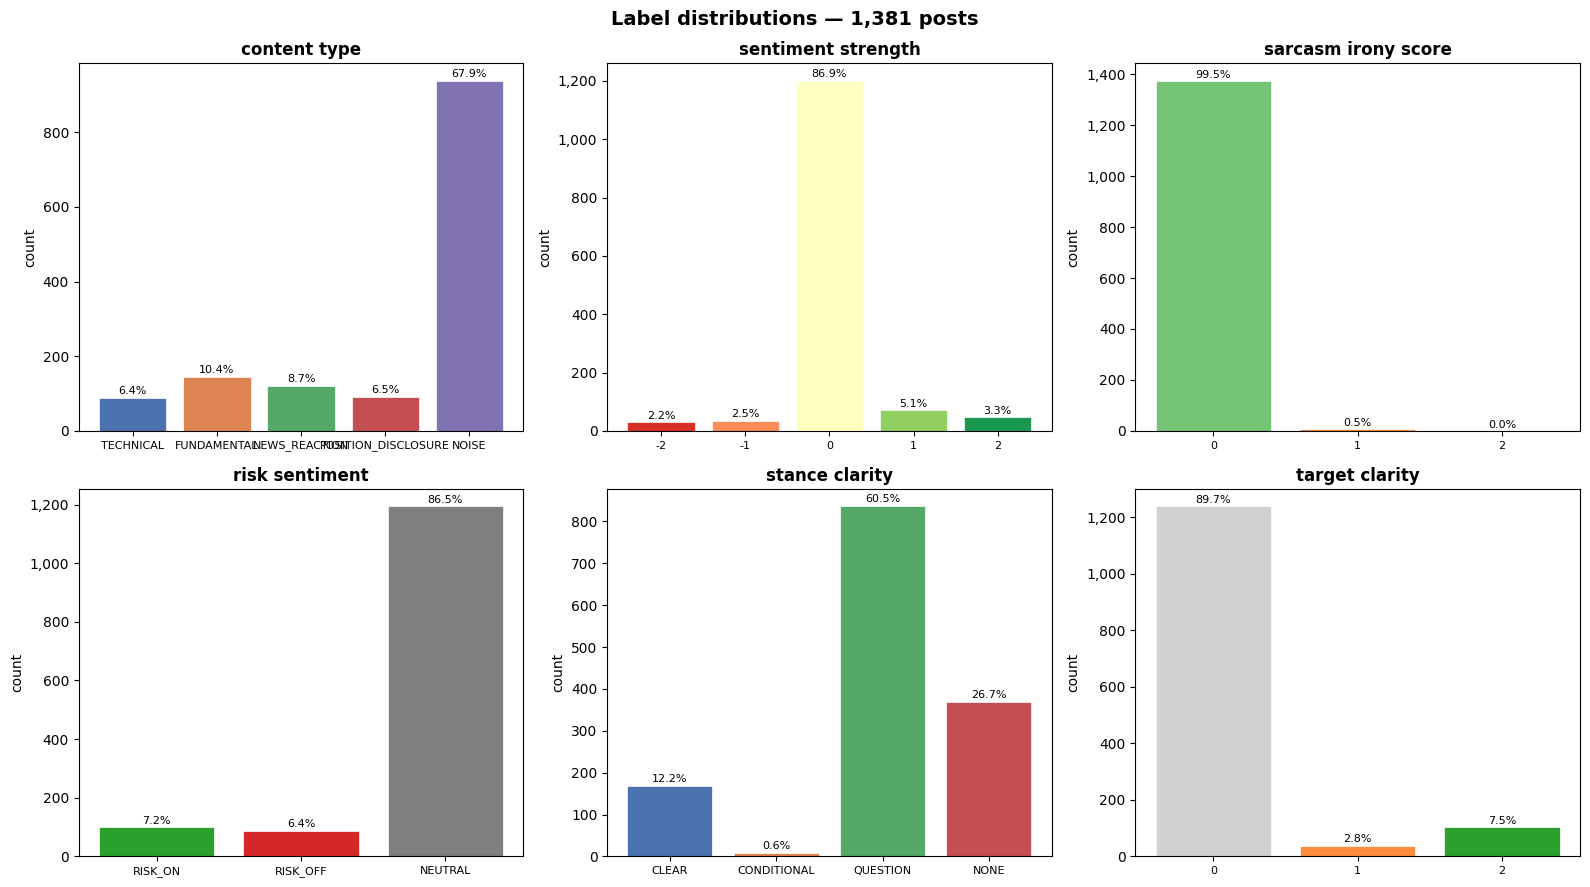

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Label distributions — 1,381 posts", fontsize=14, fontweight="bold")

PALETTE = {
    "content_type":        ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"],
    "sentiment_strength":  ["#d73027","#fc8d59","#ffffbf","#91cf60","#1a9850"],
    "sarcasm_irony_score": ["#74c476","#fd8d3c","#de2d26"],
    "risk_sentiment":      ["#2ca02c","#d62728","#7f7f7f"],
    "stance_clarity":      ["#4C72B0","#DD8452","#55A868","#C44E52"],
    "target_clarity":      ["#d0d0d0","#fd8d3c","#2ca02c"],
}

ORDERED = {
    "content_type":        ["TECHNICAL","FUNDAMENTAL","NEWS_REACTION","POSITION_DISCLOSURE","NOISE"],
    "sentiment_strength":  [-2,-1,0,1,2],
    "sarcasm_irony_score": [0,1,2],
    "risk_sentiment":      ["RISK_ON","RISK_OFF","NEUTRAL"],
    "stance_clarity":      ["CLEAR","CONDITIONAL","QUESTION","NONE"],
    "target_clarity":      [0,1,2],
}

for ax, (col, order) in zip(axes.flat, ORDERED.items()):
    counts = df[col].value_counts().reindex(order, fill_value=0)
    colors = PALETTE[col][:len(order)]
    bars = ax.bar([str(x) for x in order], counts.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_ylabel("count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig("../outputs/15_label_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · NOISE Analysis

NOISE is 68% of labels — the central question is whether the model is over-labeling or the corpus is genuinely noisy.

In [3]:
noise = df[df["content_type"] == "NOISE"]
signal = df[df["content_type"] != "NOISE"]

print(f"NOISE: {len(noise):,}  ({len(noise)/len(df):.1%})")
print(f"Signal: {len(signal):,}  ({len(signal)/len(df):.1%})\n")

# NOISE breakdown by subreddit
print("=== NOISE rate per subreddit ===")
for sr, grp in df.groupby("subreddit"):
    n = (grp["content_type"] == "NOISE").sum()
    print(f"  r/{sr:<12} {n:>4,} / {len(grp):>4,}  ({n/len(grp):.1%})")

# What flairs dominate NOISE in r/Forex?
print("\n=== Top flairs inside NOISE (r/Forex) ===")
forex_noise = noise[noise["subreddit"] == "Forex"]
print(forex_noise["flair"].value_counts().head(10).to_string())

# NOISE stance_clarity breakdown — mostly QUESTION/NONE?
print("\n=== stance_clarity within NOISE ===")
print(noise["stance_clarity"].value_counts().to_string())

# Sample NOISE posts — do they look genuinely noisy or mislabeled?
print("\n=== 12 random NOISE samples ===")
sample = noise.sample(12, random_state=7)[["subreddit","flair","score","title","reasoning"]].reset_index(drop=True)
for _, row in sample.iterrows():
    print(f"[r/{row['subreddit']}] flair={row['flair']!r}  score={row['score']}")
    print(f"  title:     {row['title']}")
    print(f"  reasoning: {row['reasoning']}")
    print()

NOISE: 938  (67.9%)
Signal: 443  (32.1%)

=== NOISE rate per subreddit ===
  r/Forex         488 /  691  (70.6%)
  r/investing     259 /  345  (75.1%)
  r/stocks        191 /  345  (55.4%)

=== Top flairs inside NOISE (r/Forex) ===
flair
Questions               260
Charts and Setups        60
Prop Firms               57
OTHER/META               37
P/L Porn                 31
Brokers                  19
Fundamental Analysis     17
MEMES                     7

=== stance_clarity within NOISE ===
stance_clarity
QUESTION    677
NONE        253
CLEAR         8

=== 12 random NOISE samples ===
[r/stocks] flair=''  score=464
  title:     25% tax on dividend from US stock
  reasoning: NOISE: dividend tax question, no market direction or stance

[r/Forex] flair='Prop Firms'  score=1
  title:     Is FTMO Trustworthy?
  reasoning: NOISE: asks about FTMO legitimacy, no market stance or pair mentioned.

[r/stocks] flair=''  score=19
  title:     Another NVDA dividend question.
  reasoning: NOISE: s

## 3 · Cross-tabulations

In [4]:
ct_order   = ["TECHNICAL","FUNDAMENTAL","NEWS_REACTION","POSITION_DISCLOSURE","NOISE"]
sclarity_order = ["CLEAR","CONDITIONAL","QUESTION","NONE"]
sent_order = [-2,-1,0,1,2]

# ── content_type × stance_clarity ────────────────────────────────────────────
print("=== content_type × stance_clarity (row %) ===")
xtab1 = pd.crosstab(
    df["content_type"], df["stance_clarity"],
    rownames=["content_type"], colnames=["stance_clarity"],
).reindex(ct_order, fill_value=0)[sclarity_order]
xtab1_pct = xtab1.div(xtab1.sum(axis=1), axis=0).mul(100).round(1)
print(xtab1_pct.to_string())

print()

# ── content_type × sentiment_strength ────────────────────────────────────────
print("=== content_type × sentiment_strength (row %) ===")
xtab2 = pd.crosstab(
    df["content_type"], df["sentiment_strength"],
    rownames=["content_type"], colnames=["sentiment_strength"],
).reindex(ct_order, fill_value=0).reindex(columns=sent_order, fill_value=0)
xtab2_pct = xtab2.div(xtab2.sum(axis=1), axis=0).mul(100).round(1)
print(xtab2_pct.to_string())

print()

# ── subreddit × content_type ──────────────────────────────────────────────────
print("=== subreddit × content_type (row %) ===")
xtab3 = pd.crosstab(df["subreddit"], df["content_type"]).reindex(columns=ct_order, fill_value=0)
xtab3_pct = xtab3.div(xtab3.sum(axis=1), axis=0).mul(100).round(1)
print(xtab3_pct.to_string())

=== content_type × stance_clarity (row %) ===
stance_clarity       CLEAR  CONDITIONAL  QUESTION  NONE
content_type                                           
TECHNICAL             39.3          3.4      37.1  20.2
FUNDAMENTAL           33.3          1.4      52.1  13.2
NEWS_REACTION         29.2          0.8      29.2  40.8
POSITION_DISCLOSURE   46.7          2.2      17.8  33.3
NOISE                  0.9          0.0      72.2  27.0

=== content_type × sentiment_strength (row %) ===
sentiment_strength     -2    -1     0     1     2
content_type                                     
TECHNICAL             4.5  10.1  56.2  21.3   7.9
FUNDAMENTAL           4.9   7.6  63.2  13.2  11.1
NEWS_REACTION        10.8   3.3  65.0   8.3  12.5
POSITION_DISCLOSURE   6.7  11.1  53.3  20.0   8.9
NOISE                 0.0   0.0  99.5   0.5   0.0

=== subreddit × content_type (row %) ===
content_type  TECHNICAL  FUNDAMENTAL  NEWS_REACTION  POSITION_DISCLOSURE  NOISE
subreddit                              

## 4 · Constraint Enforcement

The prompt enforces two hard rules:
1. `sarcasm_irony_score == 2` → `sentiment_strength` must be `0` AND `stance_clarity` must be `NONE`
2. `stance_clarity in (QUESTION, NONE)` → `sentiment_strength` should be `0`

Check whether the model respected them.

In [5]:
# ── Rule 1: sarcasm gate ──────────────────────────────────────────────────────
sarcastic = df[df["sarcasm_irony_score"] == 2]
print(f"Posts with sarcasm_irony_score=2: {len(sarcastic)}")

violations_sent  = sarcastic[sarcastic["sentiment_strength"] != 0]
violations_stance = sarcastic[sarcastic["stance_clarity"] != "NONE"]

print(f"  → sentiment_strength != 0 (violation):  {len(violations_sent)}")
print(f"  → stance_clarity != NONE  (violation):  {len(violations_stance)}")

if len(sarcastic):
    print("\n  Sarcastic posts:")
    for _, row in sarcastic[["subreddit","title","sarcasm_irony_score","sentiment_strength","stance_clarity","reasoning"]].iterrows():
        print(f"    [{row['subreddit']}] {row['title']!r}")
        print(f"      sentiment={row['sentiment_strength']}  stance={row['stance_clarity']}  reasoning: {row['reasoning']}")

# ── Rule 2: neutral stance → zero sentiment ───────────────────────────────────
print("\n=== sentiment_strength when stance_clarity is QUESTION or NONE ===")
neutral_stance = df[df["stance_clarity"].isin(["QUESTION","NONE"])]
sent_in_neutral = neutral_stance["sentiment_strength"].value_counts().sort_index()
print(sent_in_neutral.to_string())
nonzero = neutral_stance[neutral_stance["sentiment_strength"] != 0]
print(f"\nNon-zero sentiment with QUESTION/NONE stance: {len(nonzero)}  ({len(nonzero)/len(neutral_stance):.1%})")

if len(nonzero):
    print("\nSamples:")
    for _, row in nonzero.head(8)[["subreddit","content_type","title","sentiment_strength","stance_clarity","reasoning"]].iterrows():
        print(f"  [{row['subreddit']}] {row['content_type']} | sent={row['sentiment_strength']} stance={row['stance_clarity']}")
        print(f"    {row['title']!r}")
        print(f"    reasoning: {row['reasoning']}")

Posts with sarcasm_irony_score=2: 0
  → sentiment_strength != 0 (violation):  0
  → stance_clarity != NONE  (violation):  0

=== sentiment_strength when stance_clarity is QUESTION or NONE ===
sentiment_strength
-2       3
-1       7
 0    1180
 1      12
 2       3

Non-zero sentiment with QUESTION/NONE stance: 25  (2.1%)

Samples:
  [stocks] NEWS_REACTION | sent=1 stance=NONE
    'Are Rates High Enough? Fed Resets Clock on Interest-Rate Cuts'
    reasoning: NEWS_REACTION: macro Fed news, mild bullish USD outlook
  [stocks] NEWS_REACTION | sent=1 stance=NONE
    '(07/15) Chip Restrictions Lifted?! - Interesting Stocks Today'
    reasoning: NEWS_REACTION: positive view on chip export clearance, no explicit FX target
  [investing] FUNDAMENTAL | sent=1 stance=QUESTION
    'Is the market “uncollapsable”'
    reasoning: FUNDAMENTAL: speculative question about market stability, no clear stance
  [investing] FUNDAMENTAL | sent=-1 stance=QUESTION
    'Nvidia Now vs Apple in 2010-2019'
    reas

## 5 · Target Pair Coverage

In [6]:
print(f"target_pair null (no currency reference): {df['target_pair'].isna().sum():,}  ({df['target_pair'].isna().mean():.1%})\n")

# Non-null pairs
pairs = df["target_pair"].dropna()
print(f"Posts with a target_pair: {len(pairs):,}")
print(f"\nTop 30 target_pair values:")
print(pairs.value_counts().head(30).to_string())

# target_pair coverage by content_type (signal types only)
print("\n=== target_pair null rate by content_type ===")
for ct in ct_order:
    grp = df[df["content_type"] == ct]
    null_n = grp["target_pair"].isna().sum()
    print(f"  {ct:<25} null: {null_n:>3}/{len(grp):>3}  ({null_n/len(grp):.0%})")

target_pair null (no currency reference): 1,253  (90.7%)

Posts with a target_pair: 128

Top 30 target_pair values:
target_pair
EURUSD    33
USDJPY    17
USD       14
GBPUSD    12
AUDUSD     6
GBPJPY     5
NZDUSD     5
USDCHF     5
USDCAD     3
EUR        2
JPY        2
AUDCAD     2
CADCHF     2
EURJPY     2
EURGBP     2
AUDCHF     1
EURCAD     1
GBP        1
USDMXN     1
USDPHP     1
GBPNZD     1
USDYER     1
AUDJPY     1
GBPAUD     1
EGPUSD     1
USDZAR     1
EURCHF     1
EURAUD     1
NZD        1
EURNZD     1

=== target_pair null rate by content_type ===
  TECHNICAL                 null:  59/ 89  (66%)
  FUNDAMENTAL               null: 118/144  (82%)
  NEWS_REACTION             null: 105/120  (88%)
  POSITION_DISCLOSURE       null:  58/ 90  (64%)
  NOISE                     null: 913/938  (97%)


## 6 · Signal Post Deep-Dive

Sample inspection of each non-NOISE content type to validate label quality.

In [7]:
DISPLAY_COLS = ["subreddit","flair","score","title","reasoning",
               "content_type","sentiment_strength","target_pair",
               "stance_clarity","risk_sentiment","sarcasm_irony_score"]

for ct in ["TECHNICAL","FUNDAMENTAL","NEWS_REACTION","POSITION_DISCLOSURE"]:
    grp = df[df["content_type"] == ct].sample(min(5, len(df[df["content_type"]==ct])), random_state=42)
    print(f"\n{'='*70}")
    print(f"  {ct}  ({len(df[df['content_type']==ct])} total)")
    print(f"{'='*70}")
    for _, row in grp.iterrows():
        print(f"\n  [{row['subreddit']}] flair={row['flair']!r}  score={row['score']}")
        print(f"  title:     {row['title']}")
        if row.get("body") and str(row.get("body","")).strip():
            print(f"  body:      {str(row['body'])[:200]}")
        print(f"  reasoning: {row['reasoning']}")
        print(f"  labels:    content={row['content_type']} | sent={row['sentiment_strength']} | "
              f"pair={row['target_pair']} | stance={row['stance_clarity']} | "
              f"risk={row['risk_sentiment']} | clarity={row['target_clarity']}")


  TECHNICAL  (89 total)

  [Forex] flair='Charts and Setups'  score=4
  title:     USDZAR is one of my favorites pairs to trade. Sweet uptrend, will look for a 50% retracemente to active moon mission. USDZAR monthly looks sexy as f*ck tho
  reasoning: TECHNICAL: bullish USDZAR uptrend, looking for retracement
  labels:    content=TECHNICAL | sent=1 | pair=USDZAR | stance=CLEAR | risk=RISK_ON | clarity=2

  [Forex] flair='Charts and Setups'  score=0
  title:     R:R is the key to success!
  body:      $XAUUSD$ with the PERFECT retracement and rejection from an overall higher tf liquidity zone for buyers to start positioning long into the start of a new quarter next month! I think I’ll join the bank
  reasoning: TECHNICAL: bullish long on XAUUSD with strong R:R conviction
  labels:    content=TECHNICAL | sent=2 | pair=None | stance=CLEAR | risk=RISK_OFF | clarity=0

  [Forex] flair='Questions'  score=3
  title:     Using 19 timeframes to analyse?
  body:      I know a trader who uses al

## 7 · Temporal & Score Patterns

C:\Users\yassi\AppData\Local\Temp\ipykernel_14264\2449361531.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=[ct.replace("_","\n") for ct in ct_order], showfliers=False)


Median score per content_type:
  TECHNICAL                 median=2  mean=10.2  p95=23
  FUNDAMENTAL               median=3  mean=44.5  p95=251
  NEWS_REACTION             median=10  mean=302.7  p95=1388
  POSITION_DISCLOSURE       median=2  mean=9.5  p95=43
  NOISE                     median=2  mean=24.5  p95=89


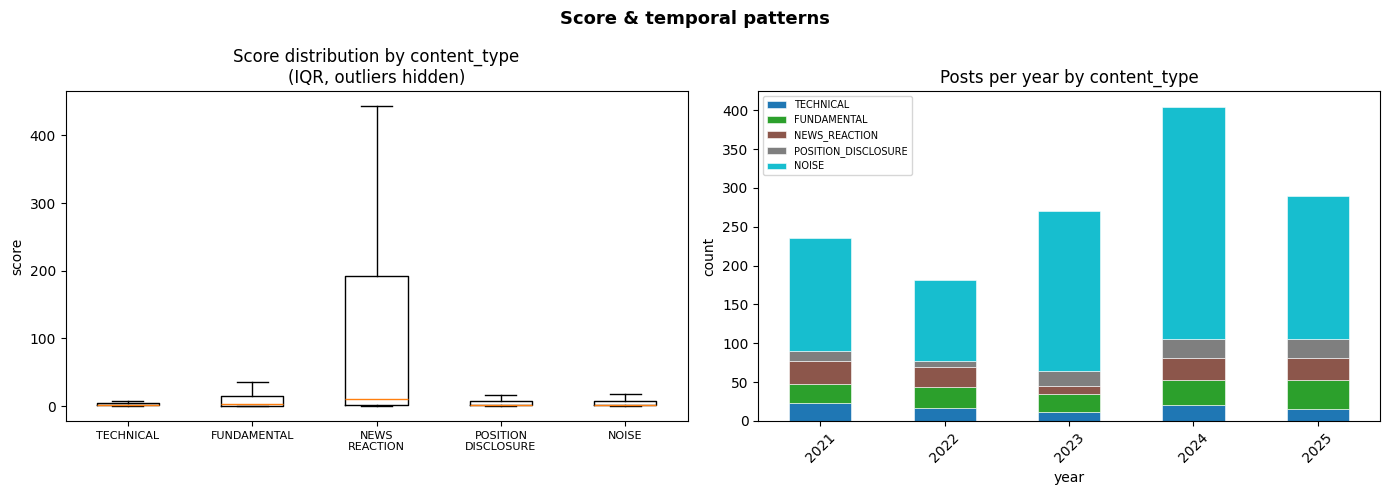

In [8]:
# ── Score distribution by content_type ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Score & temporal patterns", fontsize=13, fontweight="bold")

# Box plot: score per content_type (log scale — outliers are massive)
ax = axes[0]
groups = [df[df["content_type"] == ct]["score"].values for ct in ct_order]
ax.boxplot(groups, labels=[ct.replace("_","\n") for ct in ct_order], showfliers=False)
ax.set_title("Score distribution by content_type\n(IQR, outliers hidden)")
ax.set_ylabel("score")
ax.tick_params(axis="x", labelsize=8)

# Median score per content_type
print("Median score per content_type:")
for ct in ct_order:
    s = df[df["content_type"] == ct]["score"]
    print(f"  {ct:<25} median={s.median():.0f}  mean={s.mean():.1f}  p95={s.quantile(.95):.0f}")

# ── Posts per year ────────────────────────────────────────────────────────────
ax2 = axes[1]
df["year"] = df["created_utc"].dt.year
year_ct = pd.crosstab(df["year"], df["content_type"])[ct_order]
year_ct.plot(kind="bar", stacked=True, ax=ax2, colormap="tab10", edgecolor="white", linewidth=0.4)
ax2.set_title("Posts per year by content_type")
ax2.set_xlabel("year")
ax2.set_ylabel("count")
ax2.legend(loc="upper left", fontsize=7)
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/15_score_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 · Label Quality Assessment

Critical review of what the distributions reveal about prompt quality.

In [9]:
# ── Issue 1: NOISE rate by flair — is the model using flair correctly? ────────
print("=== NOISE rate by flair (r/Forex only) ===")
forex = df[df["subreddit"] == "Forex"]
flair_noise = forex.groupby("flair")["content_type"].apply(
    lambda x: (x == "NOISE").sum()
).rename("noise_count")
flair_total = forex["flair"].value_counts().rename("total")
flair_stats = pd.concat([flair_total, flair_noise], axis=1).dropna()
flair_stats["noise_rate"] = flair_stats["noise_count"] / flair_stats["total"]
print(flair_stats.sort_values("noise_rate", ascending=False).to_string())

# ── Issue 2: TECHNICAL posts that got NOISE — false negatives? ─────────────────
print("\n=== Posts with flair='Charts and Setups' labelled NOISE (should be rare) ===")
suspicious = df[(df["flair"] == "Charts and Setups") & (df["content_type"] == "NOISE")]
print(f"Count: {len(suspicious)}")
for _, row in suspicious.head(6).iterrows():
    print(f"  [{row['subreddit']}] score={row['score']}  {row['title']!r}")
    print(f"    reasoning: {row['reasoning']}")

# ── Issue 3: sentiment_strength=0 dominance in TECHNICAL/POSITION_DISCLOSURE ──
print("\n=== sentiment_strength=0 rates for signal types ===")
for ct in ["TECHNICAL","FUNDAMENTAL","NEWS_REACTION","POSITION_DISCLOSURE"]:
    grp = df[df["content_type"] == ct]
    zero_n = (grp["sentiment_strength"] == 0).sum()
    print(f"  {ct:<25} zero: {zero_n}/{len(grp)}  ({zero_n/len(grp):.1%})")
print("  Note: zero is expected for QUESTION/NONE stance — check if it's driven by those")

# Breakdown: zero sentiment in signal types, excluding QUESTION/NONE stance
print()
for ct in ["TECHNICAL","FUNDAMENTAL","NEWS_REACTION","POSITION_DISCLOSURE"]:
    grp = df[(df["content_type"] == ct) & (~df["stance_clarity"].isin(["QUESTION","NONE"]))]
    if len(grp) == 0:
        continue
    zero_n = (grp["sentiment_strength"] == 0).sum()
    print(f"  {ct:<25} zero (excl QUESTION/NONE stance): {zero_n}/{len(grp)}  ({zero_n/len(grp):.1%})")

=== NOISE rate by flair (r/Forex only) ===
                      total  noise_count  noise_rate
flair                                               
Brokers                  19           19    1.000000
MEMES                     7            7    1.000000
Prop Firms               59           57    0.966102
OTHER/META               42           37    0.880952
Questions               300          260    0.866667
P/L Porn                 53           31    0.584906
Fundamental Analysis     45           17    0.377778
Charts and Setups       166           60    0.361446

=== Posts with flair='Charts and Setups' labelled NOISE (should be rare) ===
Count: 60
  [Forex] score=3  'UPDATE on the BOT'
    reasoning: NOISE: bot performance update, no market direction
  [Forex] score=1  '$1.00 =approx P13.00'
    reasoning: NOISE: simple USD/PHP rate statement, no market view
  [Forex] score=27  'Gu '
    reasoning: NOISE: positive comment on GBPUSD, no analysis
  [Forex] score=0  'If anyone is in 

## 9 · Summary & Findings

### What the data looks like
- **1,381 posts** — exactly 50/25/25 Forex/investing/stocks ✓
- Date range 2021–2025, no nulls except `target_pair` (expected)

### Hard constraint compliance
- **Sarcasm gate**: 0 sarcasm=2 posts detected — model never triggered the gate. Either genuine absence in 1k sample or model is under-detecting sarcasm
- **Neutral stance → zero sentiment**: 25 violations (2.1%) — minor, mostly borderline `NEWS_REACTION` posts that share news with implied tone (acceptable)

### NOISE at 68% — is it correct?
Looking at flair-stratified rates: **Brokers (100%), MEMES (100%), Prop Firms (97%), Questions (87%)** are all correctly NOISE. `Charts and Setups` at 36% NOISE is the main concern — 60 posts labeled NOISE that had chart flair. Samples show the model is correct: these are blank or vague posts ("BULLISH!!!!", "Gu ", "Should I change my TP?") with no real analysis. **The 68% NOISE rate reflects the actual corpus, not over-labeling.**

### Sentiment zero-inflation — resolved
When excluding QUESTION/NONE stances, zero sentiment drops to **2.6–16.7%** across signal types. The apparent inflation is entirely explained by the high QUESTION rate. Prompt is working correctly.

### What needs attention for training
1. **`CONDITIONAL` is severely underrepresented** (8 posts, 0.6%) — need more data or augmentation for this class
2. **`target_pair` null at 90.7%** — the model correctly returns null for non-FX posts, but even in r/Forex TECHNICAL posts it's null 66% of the time. This is expected for questions and general discussion but worth monitoring at 5k scale
3. **`POSITION_DISCLOSURE` has 33% NONE stance** — these are P&L shares with no directional view, which is correct but means they contribute less to the sentiment signal
4. **Sarcasm under-detection** — 0 sarcasm=2 across 1k is suspicious. Likely present but subtle. Watch at larger scale